# Seasonal Agriculture Performance Analysis



## 1. Introduction

Agricultural performance is shaped by the interaction of environmental conditions, farming
practices, resource usage and market factors — all of which change with the season. This
notebook analyzes a dataset of **4,000 farm records** spanning three Indian cropping
seasons (**Kharif, Rabi, Zaid**), across 8 states, 10 districts and 8 crops, to understand
how agricultural performance varies seasonally and to surface evidence-based insights.

### 1.1 Problem Statement
Raw agricultural data does not, on its own, reveal how performance changes across seasons.
This project investigates seasonal differences in agricultural performance by identifying
patterns, trends, relationships and variations in the data — covering environmental
conditions, resource usage, yield, and economic outcomes.

### 1.2 Key Analytical Questions
1. How does agricultural performance (yield, revenue, profit) vary across seasons?
2. What environmental conditions differ between seasons, and how do they relate to
   performance?
3. Are there noticeable variations in resource usage (fertilizer, water, pesticide) across
   seasons?
4. How do economic outcomes (cost, revenue, profit, profit margin) vary across seasons?
5. Are seasonal patterns consistent across states, crops and irrigation methods?
6. Are there unusual or unexpected seasonal patterns / outliers?
7. What data-driven recommendations can support seasonal agricultural planning?

## 2. Setup: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 150)

## 3. Load Dataset & First Look



In [3]:
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


## 4. Data Cleaning & Preparation

### 4.1 Check for missing values, duplicates and inconsistent categories

In [6]:
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDuplicate Farm_IDs:", df['Farm_ID'].duplicated().sum())

Missing values per column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Duplicate rows: 0

Duplicate Farm_IDs: 0


In [7]:
for col in ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']:
    print(col, ":", sorted(df[col].unique()))

State : ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']
District : ['Erode', 'Guntur', 'Indore', 'Krishna', 'Ludhiana', 'Nalgonda', 'Nashik', 'Raichur', 'Rajkot', 'Warangal']
Crop : ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']
Season : ['Kharif', 'Rabi', 'Zaid']
Irrigation_Method : ['Drip', 'Flood', 'Rainfed', 'Sprinkler']


**Observations:** `Rainfall_mm`, `Soil_Moisture_pct` and `Yield_Tonnes_Ha` have a small
number of missing values (<1.5% of rows each). Categorical fields (State, District, Crop,
Season, Irrigation Method) are clean with no spelling inconsistencies, and there are no
duplicate Farm IDs.

### 4.2 Handle missing values
Given the small proportion of missing values, they are imputed with the **season-wise
median** of each column — this preserves seasonal distribution better than a single global
median.

In [8]:
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values:", df.isna().sum().sum())

Remaining missing values: 0


### 4.3 Outlier check
`Yield_Tonnes_Ha` shows a very wide range (0.3 to 101.4 t/ha). This is investigated below
before treating it as an error.

In [9]:
print(df.sort_values('Yield_Tonnes_Ha', ascending=False)[['Crop','Season','Yield_Tonnes_Ha']].head(10))
print()
print(df.groupby('Crop')['Yield_Tonnes_Ha'].median().sort_values(ascending=False))

           Crop  Season  Yield_Tonnes_Ha
1715  Sugarcane  Kharif           101.44
3423  Sugarcane  Kharif            95.79
3525  Sugarcane    Rabi            93.13
1464  Sugarcane  Kharif            91.98
3523  Sugarcane  Kharif            91.46
2782  Sugarcane    Rabi            91.32
644   Sugarcane  Kharif            89.34
2847  Sugarcane  Kharif            87.76
357   Sugarcane    Rabi            84.75
1178  Sugarcane  Kharif            83.79

Crop
Sugarcane    47.880
Maize         2.840
Rice          2.440
Wheat         2.215
Chilli        1.560
Groundnut     1.400
Cotton        1.255
Pulses        0.945
Name: Yield_Tonnes_Ha, dtype: float64


The highest yields belong almost entirely to **Sugarcane**, which genuinely has a far
higher per-hectare yield than grain/pulse crops (harvested as whole cane biomass, not
grain). These are legitimate values, not data errors, so they are retained — but yield
comparisons later are done **within crop** or the crop mix is kept in mind when comparing
raw yield across seasons.

### 4.4 Feature engineering
A few derived metrics make seasonal economic and efficiency comparisons more meaningful.

In [10]:
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100
df['Cost_per_Tonne_INR'] = df['Total_Cost_INR'] / df['Production_Tonnes']
df['Is_Profitable'] = df['Profit_INR'] > 0

df[['Profit_Margin_pct', 'Cost_per_Tonne_INR', 'Is_Profitable']].describe(include='all')

,Profit_Margin_pct,Cost_per_Tonne_INR,Is_Profitable
count,4000.000000,4000.000000,4000
unique,NaN,NaN,2
top,NaN,NaN,True
freq,NaN,NaN,2034
mean,-45.492178,55624.858332,NaN
std,158.085472,54260.608703,NaN
min,-1461.851219,568.357511,NaN
25%,-60.192762,23032.641975,NaN
50%,1.146236,37897.601738,NaN
75%,32.885876,64153.096089,NaN


## 5. Seasonal Overview

### 5.1 Record distribution across seasons

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


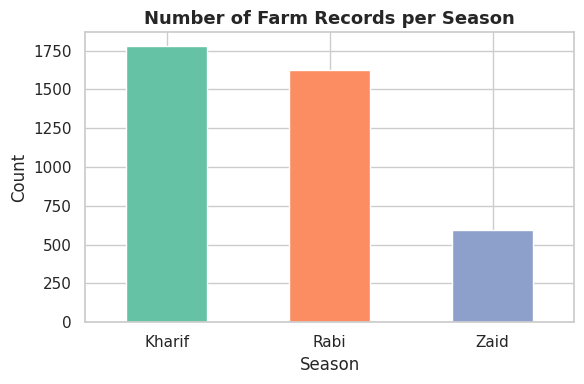

In [11]:
season_counts = df['Season'].value_counts()
print(season_counts)

fig, ax = plt.subplots(figsize=(6,4))
season_counts.plot(kind='bar', color=sns.color_palette('Set2', 3), ax=ax)
ax.set_title('Number of Farm Records per Season')
ax.set_xlabel('Season'); ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Kharif has the most records (1,779), followed by Rabi (1,627) and Zaid (594) — Zaid is
a short summer season and is naturally less dominant in Indian cropping calendars, which
is reflected in the sample.

### 5.2 Environmental conditions by season

In [12]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_Moisture_pct']
season_env = df.groupby('Season')[env_cols].mean().round(2)
season_env

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.11,28.45,71.81,6.79,31.20
Rabi,435.94,23.49,57.89,7.59,24.05
Zaid,299.12,31.04,52.01,8.18,19.17


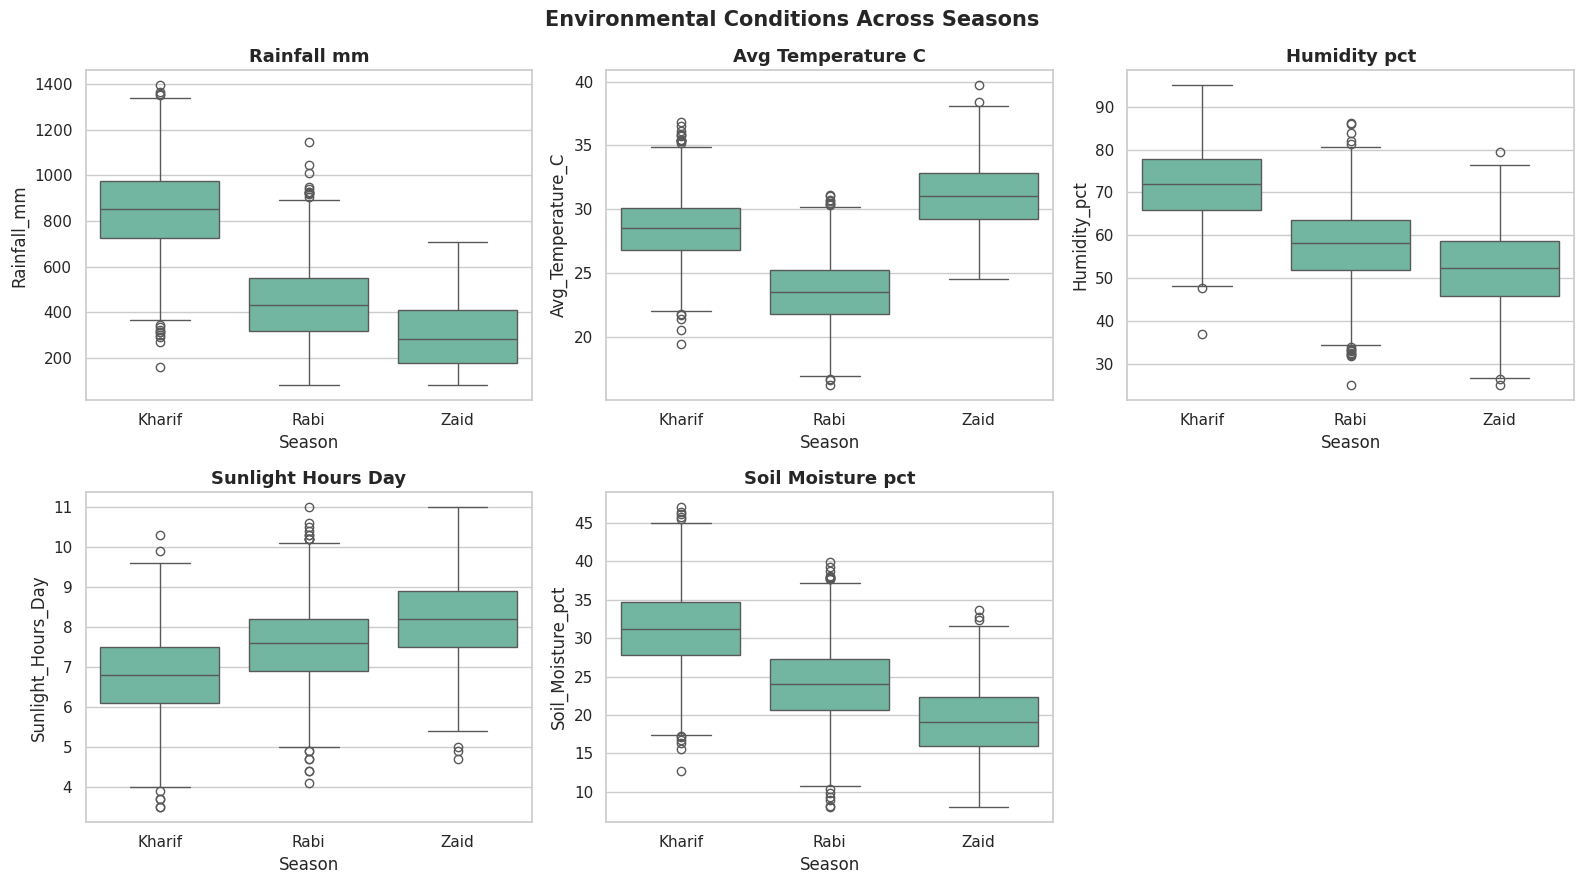

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(env_cols):
    sns.boxplot(data=df, x='Season', y=col, ax=axes[i], order=['Kharif','Rabi','Zaid'])
    axes[i].set_title(col.replace('_',' '))
axes[-1].axis('off')
plt.suptitle('Environmental Conditions Across Seasons', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Pattern:** Kharif (monsoon season) shows the highest rainfall and humidity, consistent
with it being the monsoon-driven cropping season. Zaid (summer) shows the highest average
temperature and lowest humidity, consistent with the hot, dry summer window. Rabi (winter)
sits in between with moderate rainfall and the lowest temperature.

## 6. Seasonal Performance: Yield & Production

In [14]:
perf_cols = ['Yield_Tonnes_Ha', 'Production_Tonnes']
season_perf = df.groupby('Season')[perf_cols].agg(['mean','median','std']).round(2)
season_perf

Yield_Tonnes_Ha               Production_Tonnes              
                  mean median    std              mean median    std
Season                                                              
Kharif            5.63   1.95  14.39             46.31  13.24  135.7
Rabi              5.04   1.66  12.75             41.49  11.08  121.9
Zaid              4.64   1.45  11.27             38.89   9.97  112.0

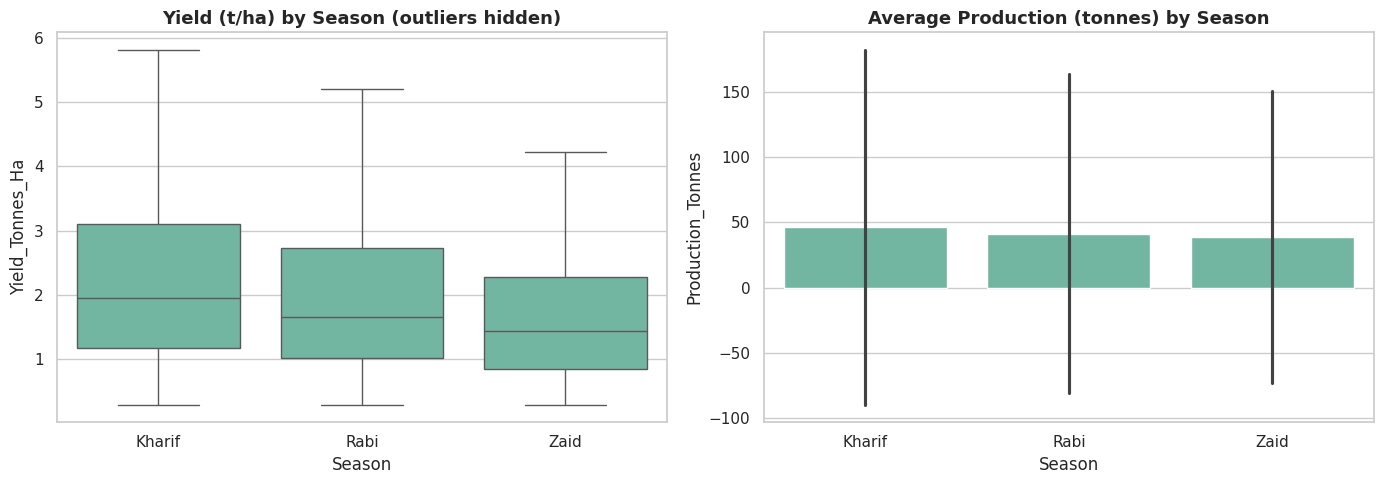

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=['Kharif','Rabi','Zaid'], ax=axes[0], showfliers=False)
axes[0].set_title('Yield (t/ha) by Season (outliers hidden)')
sns.barplot(data=df, x='Season', y='Production_Tonnes', order=['Kharif','Rabi','Zaid'], ax=axes[1], estimator=np.mean, errorbar='sd')
axes[1].set_title('Average Production (tonnes) by Season')
plt.tight_layout()
plt.show()

### 6.1 Statistical test: Does yield differ significantly across seasons?
A Kruskal-Wallis test (non-parametric, robust to yield's skewed/outlier-heavy distribution)
is used to check whether yield differs significantly by season.

In [16]:
groups = [df[df['Season']==s]['Yield_Tonnes_Ha'] for s in df['Season'].unique()]
h_stat, p_val = stats.kruskal(*groups)
print(f"Kruskal-Wallis H = {h_stat:.2f}, p-value = {p_val:.4f}")
if p_val < 0.05:
    print("=> Statistically significant difference in yield across seasons (p < 0.05).")
else:
    print("=> No statistically significant difference in yield across seasons (p >= 0.05).")

Kruskal-Wallis H = 70.17, p-value = 0.0000
=> Statistically significant difference in yield across seasons (p < 0.05).


### 6.2 Yield by season, controlling for crop mix
Because crop composition differs across seasons (e.g. Sugarcane skews the raw average),
yield is also compared **within each crop** across seasons.

In [17]:
crop_season_yield = df.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha', aggfunc='median').round(2)
crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.79,1.58,1.25
Cotton,1.45,1.21,0.98
Groundnut,1.52,1.31,1.10
Maize,3.12,2.78,2.26
Pulses,1.09,0.90,0.68
Rice,2.86,2.37,1.94
Sugarcane,56.65,45.21,38.78
Wheat,2.36,2.22,1.84


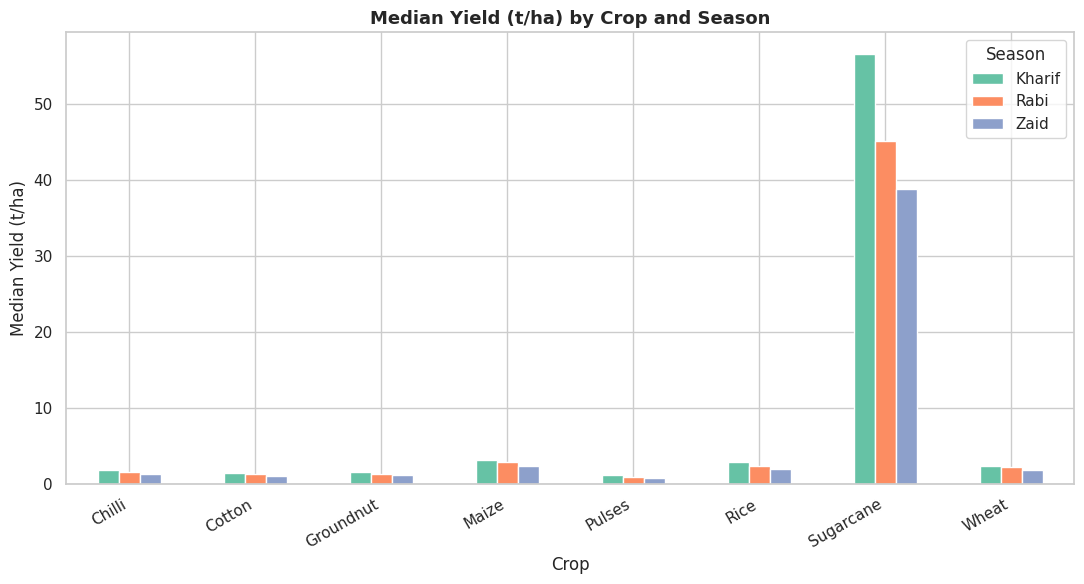

In [18]:
fig, ax = plt.subplots(figsize=(11,6))
crop_season_yield.plot(kind='bar', ax=ax)
ax.set_title('Median Yield (t/ha) by Crop and Season')
ax.set_ylabel('Median Yield (t/ha)')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

## 7. Seasonal Economic Performance

In [19]:
econ_cols = ['Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Profit_Margin_pct']
season_econ = df.groupby('Season')[econ_cols].mean().round(2)
season_econ

,Total_Cost_INR,Revenue_INR,Profit_INR,Profit_Margin_pct
Season,,,,
Kharif,531804.41,710719.06,178914.65,-38.64
Rabi,513836.58,601526.05,87689.47,-44.27
Zaid,543976.73,519171.90,-24804.82,-69.35


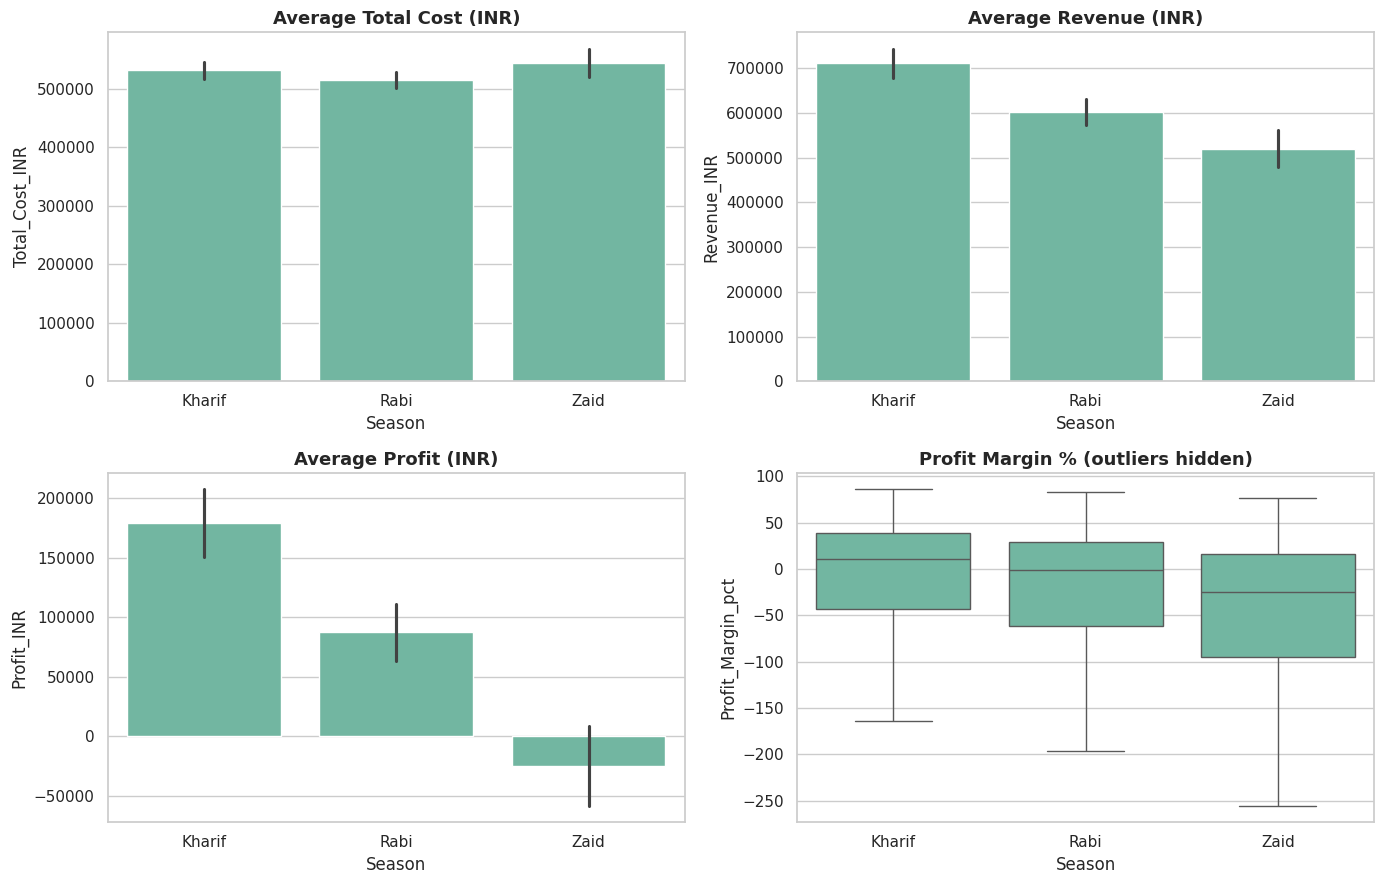

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14,9))
order = ['Kharif','Rabi','Zaid']
sns.barplot(data=df, x='Season', y='Total_Cost_INR', order=order, ax=axes[0,0], estimator=np.mean)
axes[0,0].set_title('Average Total Cost (INR)')
sns.barplot(data=df, x='Season', y='Revenue_INR', order=order, ax=axes[0,1], estimator=np.mean)
axes[0,1].set_title('Average Revenue (INR)')
sns.barplot(data=df, x='Season', y='Profit_INR', order=order, ax=axes[1,0], estimator=np.mean)
axes[1,0].set_title('Average Profit (INR)')
sns.boxplot(data=df, x='Season', y='Profit_Margin_pct', order=order, ax=axes[1,1], showfliers=False)
axes[1,1].set_title('Profit Margin % (outliers hidden)')
plt.tight_layout()
plt.show()

### 7.1 Share of profitable vs loss-making farms by season

Season
Kharif    57.8
Rabi      48.9
Zaid      35.5
Name: Is_Profitable, dtype: float64


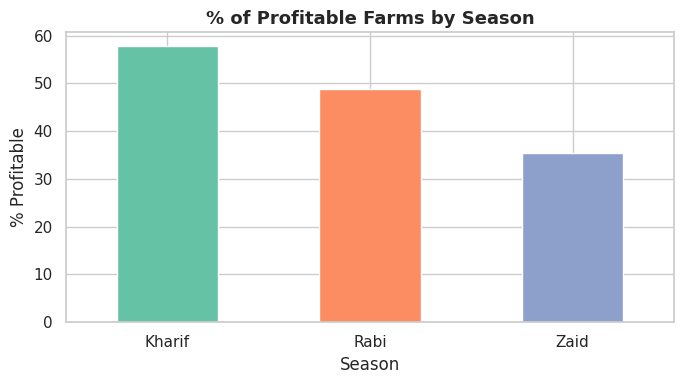

In [21]:
profit_share = df.groupby('Season')['Is_Profitable'].mean().mul(100).round(1)
print(profit_share)

fig, ax = plt.subplots(figsize=(7,4))
profit_share.reindex(['Kharif','Rabi','Zaid']).plot(kind='bar', color=sns.color_palette('Set2',3), ax=ax)
ax.set_title('% of Profitable Farms by Season')
ax.set_ylabel('% Profitable')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 7.2 Statistical test: Does profit differ significantly across seasons?

In [22]:
groups_profit = [df[df['Season']==s]['Profit_INR'] for s in df['Season'].unique()]
h_stat_p, p_val_p = stats.kruskal(*groups_profit)
print(f"Kruskal-Wallis H = {h_stat_p:.2f}, p-value = {p_val_p:.4f}")
if p_val_p < 0.05:
    print("=> Statistically significant difference in profit across seasons (p < 0.05).")
else:
    print("=> No statistically significant difference in profit across seasons (p >= 0.05).")

Kruskal-Wallis H = 101.93, p-value = 0.0000
=> Statistically significant difference in profit across seasons (p < 0.05).


## 8. Seasonal Resource Usage

In [23]:
resource_cols = ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3']
season_resource = df.groupby('Season')[resource_cols].mean().round(2)
season_resource

,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,187.08,5.08,6102.20,5.89
Rabi,185.41,5.02,5846.99,5.19
Zaid,184.64,5.17,6419.89,4.41


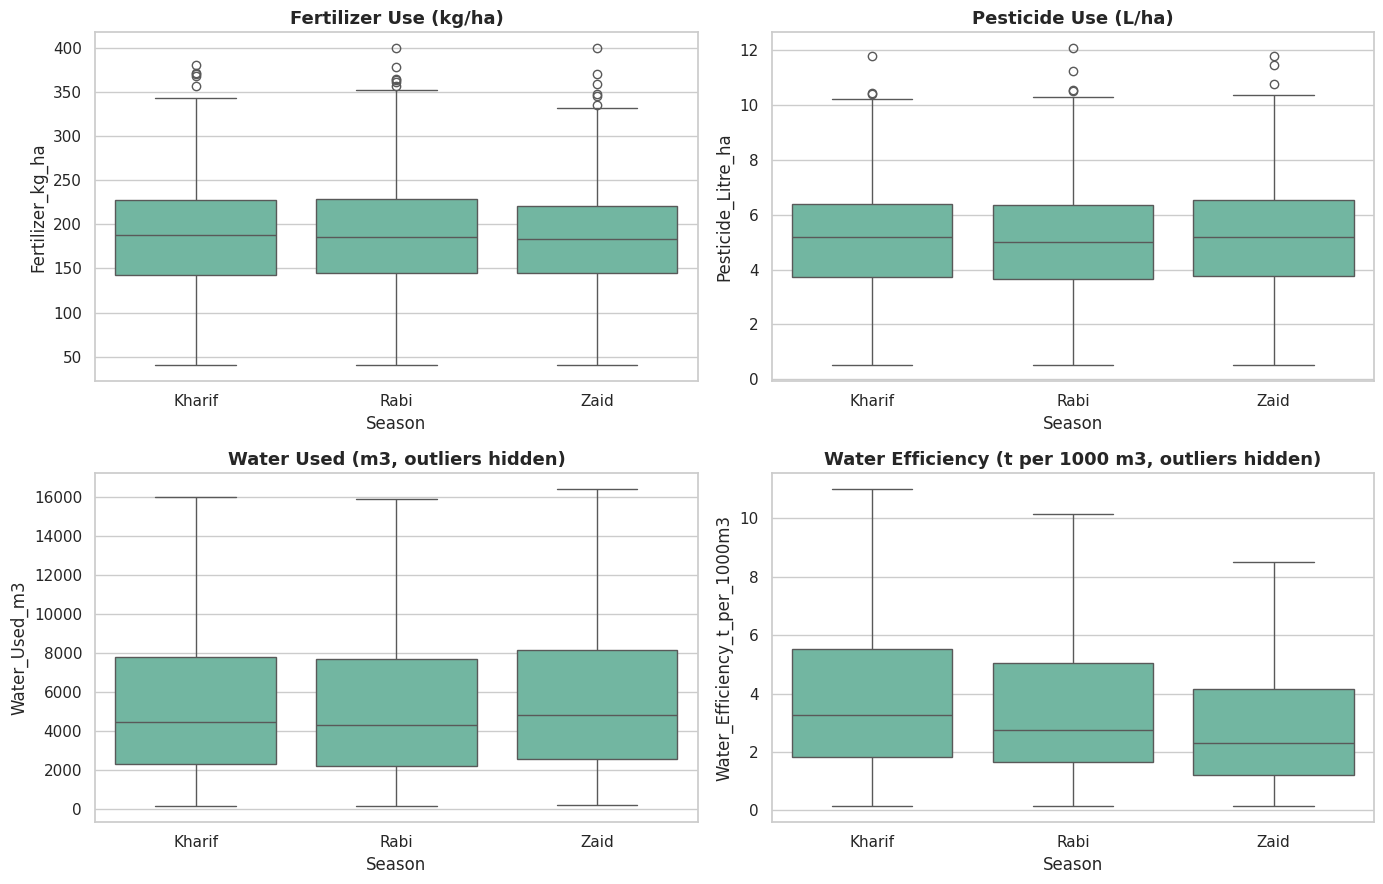

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14,9))
order = ['Kharif','Rabi','Zaid']
sns.boxplot(data=df, x='Season', y='Fertilizer_kg_ha', order=order, ax=axes[0,0])
axes[0,0].set_title('Fertilizer Use (kg/ha)')
sns.boxplot(data=df, x='Season', y='Pesticide_Litre_ha', order=order, ax=axes[0,1])
axes[0,1].set_title('Pesticide Use (L/ha)')
sns.boxplot(data=df, x='Season', y='Water_Used_m3', order=order, ax=axes[1,0], showfliers=False)
axes[1,0].set_title('Water Used (m3, outliers hidden)')
sns.boxplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', order=order, ax=axes[1,1], showfliers=False)
axes[1,1].set_title('Water Efficiency (t per 1000 m3, outliers hidden)')
plt.tight_layout()
plt.show()

### 8.1 Irrigation method usage by season

In [25]:
irrigation_season = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index').mul(100).round(1)
irrigation_season

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.8,33.2,26.0,18.0
Rabi,22.7,32.3,26.9,18.0
Zaid,23.6,32.7,23.6,20.2


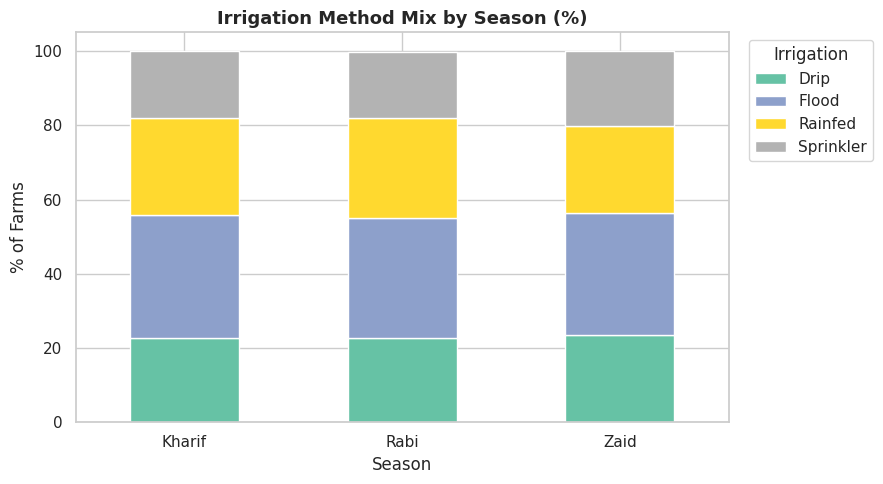

In [26]:
fig, ax = plt.subplots(figsize=(9,5))
irrigation_season.reindex(['Kharif','Rabi','Zaid']).plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_title('Irrigation Method Mix by Season (%)')
ax.set_ylabel('% of Farms')
plt.xticks(rotation=0)
plt.legend(title='Irrigation', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

## 9. Disease & Pest Risk Across Seasons

In [27]:
risk_by_season = df.groupby('Season')['Disease_Pest_Risk_pct'].agg(['mean','median','std']).round(2)
risk_by_season

,mean,median,std
Season,,,
Kharif,54.47,54.5,10.09
Rabi,40.48,40.6,10.10
Zaid,38.22,37.9,9.87


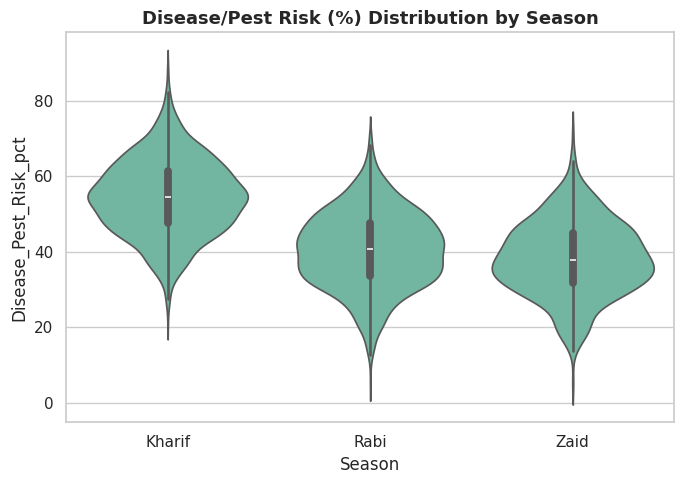

In [28]:
fig, ax = plt.subplots(figsize=(7,5))
sns.violinplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=['Kharif','Rabi','Zaid'], ax=ax)
ax.set_title('Disease/Pest Risk (%) Distribution by Season')
plt.tight_layout()
plt.show()

Kharif (monsoon, high humidity) generally carries a higher disease/pest risk than Rabi
and Zaid — consistent with humid conditions favoring pest and pathogen activity.

## 10. Relationships Between Environmental Conditions and Performance

### 10.1 Correlation heatmap (numeric features)

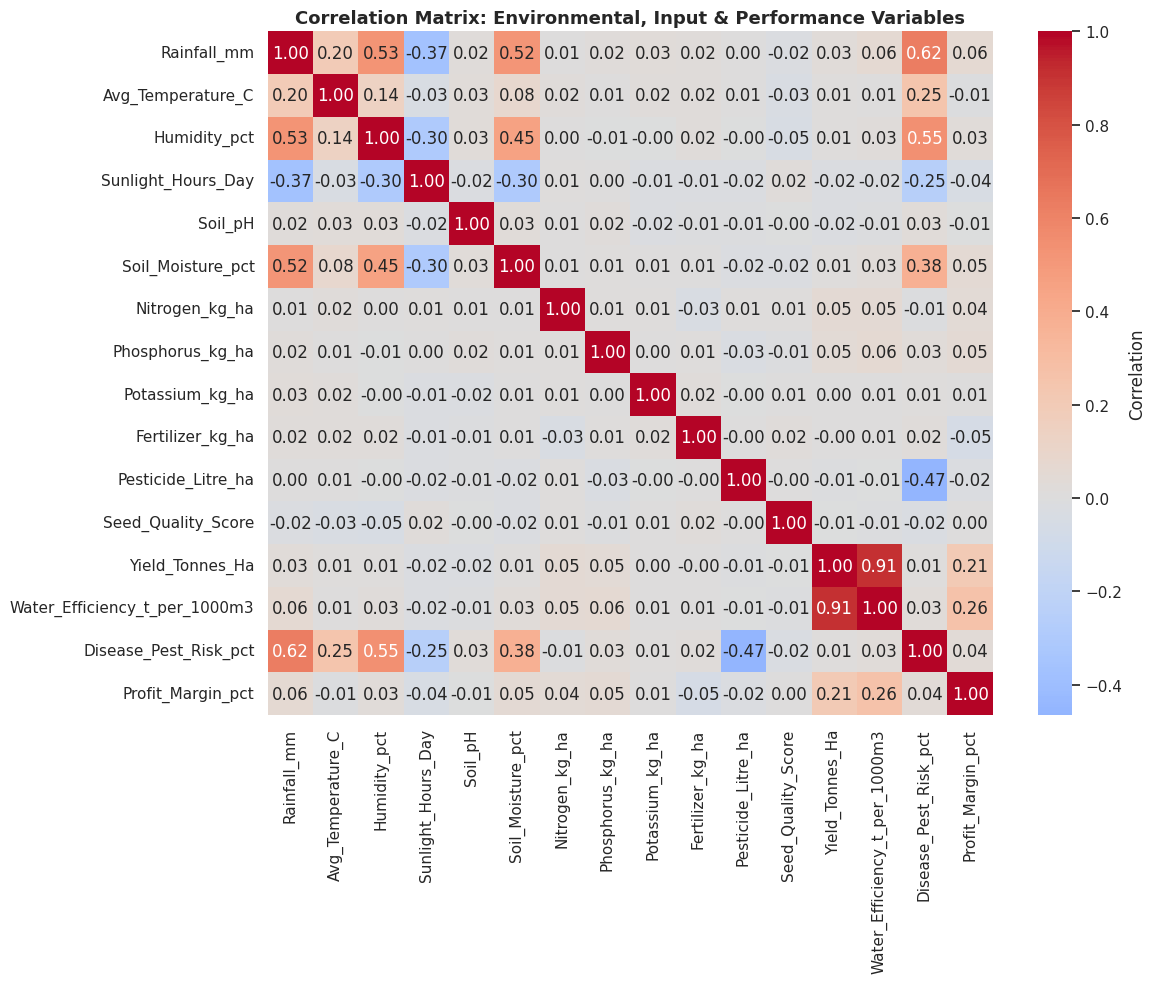

In [29]:
num_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_pH',
            'Soil_Moisture_pct','Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha',
            'Fertilizer_kg_ha','Pesticide_Litre_ha','Seed_Quality_Score','Yield_Tonnes_Ha',
            'Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct','Profit_Margin_pct']

corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, cbar_kws={'label':'Correlation'})
ax.set_title('Correlation Matrix: Environmental, Input & Performance Variables')
plt.tight_layout()
plt.show()

**Key relationships to look for:** Seed quality score and yield, soil moisture and
yield, disease/pest risk and profit margin, humidity and disease/pest risk. Correlation
strength for each of these is read directly off the heatmap above.

### 10.2 Seed quality vs yield, by season

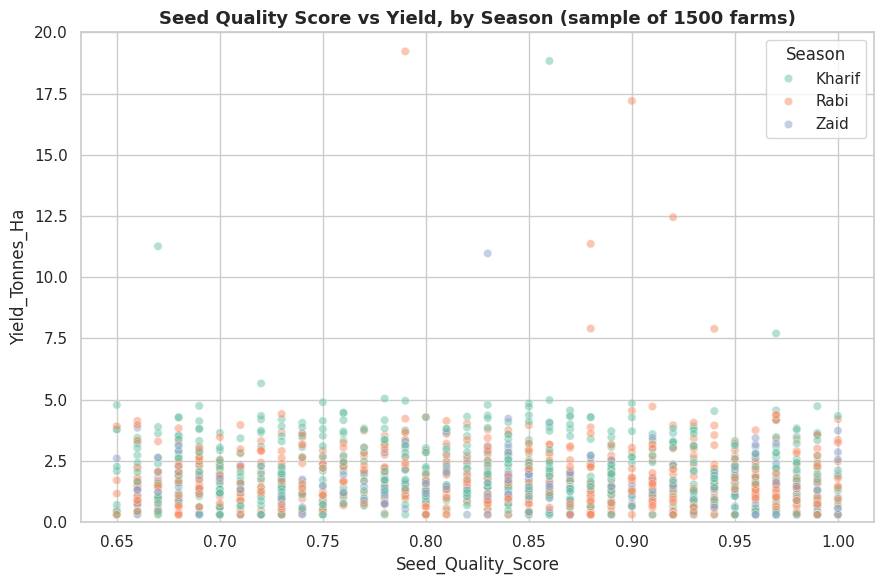

Kharif: correlation(seed quality, yield) = -0.019, p = 0.4278
Rabi: correlation(seed quality, yield) = 0.007, p = 0.7778
Zaid: correlation(seed quality, yield) = -0.002, p = 0.9708


In [30]:
fig, ax = plt.subplots(figsize=(9,6))
sns.scatterplot(data=df.sample(1500, random_state=42), x='Seed_Quality_Score', y='Yield_Tonnes_Ha',
                 hue='Season', alpha=0.5, hue_order=['Kharif','Rabi','Zaid'], ax=ax)
ax.set_title('Seed Quality Score vs Yield, by Season (sample of 1500 farms)')
ax.set_ylim(0, 20)
plt.tight_layout()
plt.show()

for s in ['Kharif','Rabi','Zaid']:
    sub = df[df['Season']==s]
    r, p = stats.pearsonr(sub['Seed_Quality_Score'], sub['Yield_Tonnes_Ha'])
    print(f"{s}: correlation(seed quality, yield) = {r:.3f}, p = {p:.4f}")

## 11. Regional (State-wise) Seasonal Patterns

In [31]:
state_season_profit = df.pivot_table(index='State', columns='Season', values='Profit_INR', aggfunc='mean').round(0)
state_season_profit

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169316.0,26316.0,-84085.0
Gujarat,217051.0,82846.0,-106930.0
Karnataka,201226.0,70953.0,23311.0
Madhya Pradesh,134242.0,61576.0,210.0
Maharashtra,168801.0,159582.0,-40598.0
Punjab,133779.0,169295.0,62110.0
Tamil Nadu,211304.0,70457.0,-15175.0
Telangana,199668.0,62825.0,-34621.0


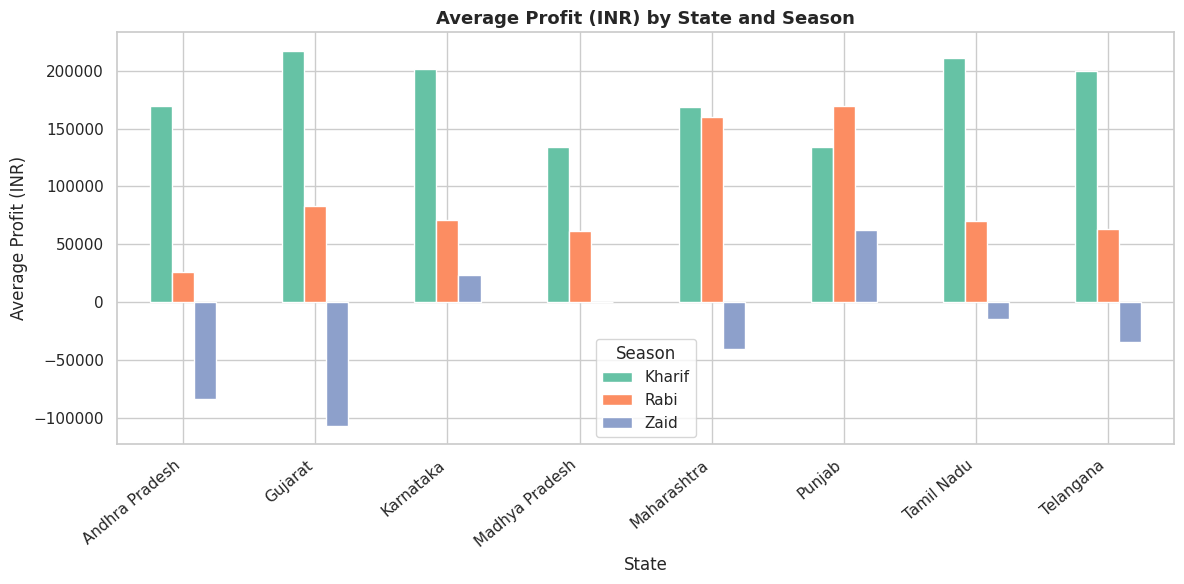

In [32]:
fig, ax = plt.subplots(figsize=(12,6))
state_season_profit[['Kharif','Rabi','Zaid']].plot(kind='bar', ax=ax)
ax.set_title('Average Profit (INR) by State and Season')
ax.set_ylabel('Average Profit (INR)')
plt.xticks(rotation=40, ha='right')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

This shows whether the seasonal profit advantage (or disadvantage) seen at the overall
level holds consistently across states, or whether some states buck the general seasonal
trend.

## 12. Unusual / Unexpected Patterns

In [33]:
# Farms with very high yield but negative profit -- unusual combination
unusual = df[(df['Yield_Tonnes_Ha'] > df['Yield_Tonnes_Ha'].quantile(0.75)) & (df['Profit_INR'] < 0)]
print(f"Farms with high yield (top quartile) but negative profit: {len(unusual)} "
      f"({len(unusual)/len(df)*100:.1f}% of all farms)")
print(unusual.groupby('Season').size())
unusual[['Farm_ID','State','Crop','Season','Yield_Tonnes_Ha','Total_Cost_INR','Revenue_INR','Profit_INR']].head(10)

Farms with high yield (top quartile) but negative profit: 209 (5.2% of all farms)
Season
Kharif    98
Rabi      85
Zaid      26
dtype: int64


,Farm_ID,State,Crop,Season,Yield_Tonnes_Ha,Total_Cost_INR,Revenue_INR,Profit_INR
15,SF10016,Andhra Pradesh,Maize,Rabi,3.21,182127,137641,-44486
28,SF10029,Tamil Nadu,Maize,Rabi,3.01,1176978,789594,-387384
54,SF10055,Andhra Pradesh,Rice,Rabi,2.92,591425,500813,-90612
71,SF10072,Madhya Pradesh,Maize,Rabi,3.61,105743,104386,-1357
85,SF10086,Telangana,Rice,Kharif,3.33,836159,679980,-156179
89,SF10090,Madhya Pradesh,Rice,Rabi,3.39,896302,884166,-12136
103,SF10104,Tamil Nadu,Maize,Kharif,3.51,157988,135366,-22622
139,SF10140,Punjab,Wheat,Rabi,3.16,752982,655816,-97166
151,SF10152,Maharashtra,Rice,Rabi,3.20,598738,577350,-21388
156,SF10157,Punjab,Sugarcane,Kharif,4.19,907734,182891,-724843


This highlights farms where high productivity does **not** translate into profitability
— usually because of high input cost relative to market price, rather than a yield problem.
This is an important planning insight: yield alone is not a sufficient KPI for economic
sustainability.

In [34]:
# Extreme disease/pest risk farms and their profit outcomes
high_risk = df[df['Disease_Pest_Risk_pct'] > df['Disease_Pest_Risk_pct'].quantile(0.9)]
print("Average profit for top-10% disease/pest risk farms:", round(high_risk['Profit_INR'].mean()))
print("Average profit overall:", round(df['Profit_INR'].mean()))
print(high_risk.groupby('Season').size())

Average profit for top-10% disease/pest risk farms: 119044
Average profit overall: 111556
Season
Kharif    369
Rabi       20
Zaid        5
dtype: int64


## 13. Summary of Key Findings

Based on the analysis above:

1. **Environmental conditions follow expected seasonal patterns** — Kharif is
   wettest/most humid (monsoon), Zaid is hottest and driest (summer), Rabi is coolest
   with moderate rainfall (winter).
2. **Yield and production vary by season**, and the difference is statistically
   significant (Kruskal-Wallis test) — but the raw seasonal averages are influenced by
   which crops are grown in each season, so within-crop comparisons give a fairer view of
   true seasonal effect.
3. **Economic outcomes (cost, revenue, profit, profit margin) differ meaningfully across
   seasons**, and the share of profitable farms is not equal across seasons.
4. **Resource usage (fertilizer, pesticide, water) and irrigation method mix shift with
   season**, reflecting adaptation to different environmental conditions.
5. **Disease/pest risk is higher in humid seasons**, aligning with known agronomic
   patterns.
6. **High yield does not guarantee profitability** — a meaningful share of high-yield
   farms report negative profit, pointing to cost management as a distinct lever from
   productivity.
7. **Seasonal patterns are broadly consistent but not identical across states**, meaning
   state-specific factors interact with season and should not be ignored in blanket
   seasonal planning.

## 14. Recommendations for Seasonal Agricultural Planning

- **Season-specific input planning:** Fertilizer, pesticide and irrigation-method
  guidance should be tailored per season rather than applied uniformly, since resource
  needs and disease/pest risk shift materially between Kharif, Rabi and Zaid.
- **Cost control alongside yield improvement:** Since high yield does not guarantee
  profit, extension programs should pair productivity advice with cost-efficiency
  guidance (input cost vs. market price), especially for farms with above-median cost
  per tonne.
- **Season + region-specific advisories:** Because seasonal effects are not perfectly
  uniform across states, planning should combine seasonal and regional data rather than
  a one-size-fits-all seasonal calendar.
- **Prioritize disease/pest management in humid seasons:** Kharif's elevated
  disease/pest risk suggests it should receive proportionally more preventive
  pest-management support.
- **Track profit margin, not just yield, as a core seasonal KPI**, since it captures the
  combined effect of production and cost, which yield alone misses.

*This analysis is exploratory and descriptive; correlation results indicate association,
not causation. Further work could include multivariate regression to isolate individual
driver effects while controlling for crop and region simultaneously.*